<a href="https://colab.research.google.com/github/japhia16/AI-Assisted-Underwriting-Triage-Agent/blob/main/Student3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install xgboost shap statsmodels

In [2]:
import pandas as pd
import numpy as np
import pickle
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from xgboost import XGBRegressor
import shap
import statsmodels.api as sm

print("All libraries loaded.")

All libraries loaded.


In [3]:
df = pd.read_csv("submissions_with_premium.csv")

print("Shape:", df.shape)
print()
print("GLM Pure Premium column check:")
print(df["GLM_Pure_Premium"].describe().round(2))
print()
print("First 3 rows of key columns:")
df[["GLM_Pure_Premium", "freq_pred", "sev_pred", "Risk_Label"]].head(3)

Shape: (5025, 64)

GLM Pure Premium column check:
count       5025.00
mean     3405712.39
std       976912.40
min      1422706.29
25%      2686159.47
50%      3265248.65
75%      3996279.47
max      8523821.81
Name: GLM_Pure_Premium, dtype: float64

First 3 rows of key columns:


,GLM_Pure_Premium,freq_pred,sev_pred,Risk_Label
0,3.852070e+06,1.523830,2.527887e+06,Medium
1,3.500568e+06,1.452624,2.409823e+06,Low
2,2.829922e+06,1.407373,2.010782e+06,Medium


In [4]:
drop_cols = [
    "Submission_ID", "District", "State", "Match_Type",
    "Match_Score", "Risk_Score_Raw", "Risk_Label",
    "Claim_Count", "Claim_Severity_INR",
    "Flood_Percent_Area", "Seismic_Zone",
    "Seismic_Risk_Level", "Cyclone_Exposure",
    "freq_pred", "sev_pred", "GLM_Pure_Premium",
    "XGB_Prediction", "Capped_Uplift_Pct",
    "Final_Premium_INR", "Raw_Uplift_Pct"
]

drop_cols    = [c for c in drop_cols if c in df.columns]
feature_cols = [c for c in df.columns if c not in drop_cols]

X = df[feature_cols]
y = df["GLM_Pure_Premium"]

print(f"Features: {len(feature_cols)}")
print(f"Rows:     {len(X)}")
print()
print("Feature list:")
for i, col in enumerate(feature_cols, 1):
    print(f"  {i}. {col}")

Features: 55
Rows:     5025

Feature list:
  1. Building_Age_Years
  2. Sum_Insured_INR
  3. Number_of_Employees
  4. Years_in_Business
  5. Prior_Claims_Count
  6. Deductible_INR
  7. Flood_Risk_Score
  8. Cyclone_Risk_Score
  9. Rainfall_Risk_Score
  10. Earthquake_Risk_Score
  11. Occupancy_Cold Storage Facility
  12. Occupancy_Educational Campus
  13. Occupancy_Factory / Manufacturing Unit
  14. Occupancy_Hospital / Clinic
  15. Occupancy_Hotel / Resort
  16. Occupancy_Office Building
  17. Occupancy_Retail Store
  18. Occupancy_Shopping Mall
  19. Occupancy_Unknown
  20. Occupancy_Warehouse
  21. Occupancy_Workshop / Fabrication Unit
  22. Construction_Type_Brick & Mortar
  23. Construction_Type_Pre-Engineered Steel Building
  24. Construction_Type_RCC (Reinforced Cement Concrete)
  25. Construction_Type_Steel Frame
  26. Construction_Type_Unknown
  27. Industry_Type_Agro Processing
  28. Industry_Type_Auto Components
  29. Industry_Type_Cement & Building Materials
  30. Industry_

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print(f"Training rows: {len(X_train)}")
print(f"Test rows:     {len(X_test)}")

Training rows: 4020
Test rows:     1005


In [6]:
xgb_model = XGBRegressor(
    n_estimators=300,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1
)

xgb_model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    verbose=50
)

with open("xgb_model.pkl", "wb") as f:
    pickle.dump(xgb_model, f)

print("\nXGBoost trained and saved.")

[0]	validation_0-rmse:914575.67924
[50]	validation_0-rmse:459061.70416
[100]	validation_0-rmse:330894.80431
[150]	validation_0-rmse:263164.61204
[200]	validation_0-rmse:222067.25533
[250]	validation_0-rmse:196975.59956
[299]	validation_0-rmse:181450.73260

XGBoost trained and saved.


In [7]:
xgb_test_preds = xgb_model.predict(X_test)
glm_test_preds = y_test

print("=" * 45)
print("MODEL COMPARISON ON TEST SET")
print("=" * 45)

for label, preds in [("GLM (baseline)", glm_test_preds),
                      ("XGBoost",        xgb_test_preds)]:
    mae  = mean_absolute_error(y_test, preds)
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    r2   = r2_score(y_test, preds)
    print(f"\n{label}")
    print(f"  MAE  (avg error in INR):      {mae:,.0f}")
    print(f"  RMSE (penalises big errors):  {rmse:,.0f}")
    print(f"  R2   (closer to 1 = better):  {r2:.4f}")

print()
print("Lower MAE/RMSE = better. Higher R2 = better.")

MODEL COMPARISON ON TEST SET

GLM (baseline)
  MAE  (avg error in INR):      0
  RMSE (penalises big errors):  0
  R2   (closer to 1 = better):  1.0000

XGBoost
  MAE  (avg error in INR):      128,635
  RMSE (penalises big errors):  181,451
  R2   (closer to 1 = better):  0.9624

Lower MAE/RMSE = better. Higher R2 = better.


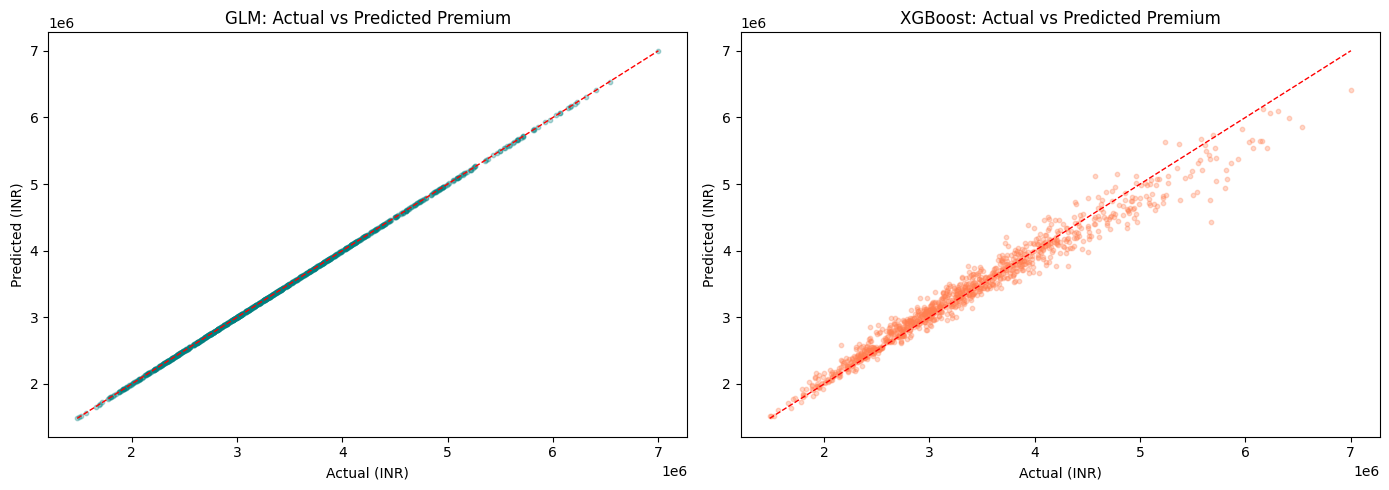

Saved: model_comparison_plot.png


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(y_test, glm_test_preds,
                alpha=0.3, color="teal", s=10)
axes[0].plot([y_test.min(), y_test.max()],
             [y_test.min(), y_test.max()], 'r--', linewidth=1)
axes[0].set_title("GLM: Actual vs Predicted Premium")
axes[0].set_xlabel("Actual (INR)")
axes[0].set_ylabel("Predicted (INR)")

axes[1].scatter(y_test, xgb_test_preds,
                alpha=0.3, color="coral", s=10)
axes[1].plot([y_test.min(), y_test.max()],
             [y_test.min(), y_test.max()], 'r--', linewidth=1)
axes[1].set_title("XGBoost: Actual vs Predicted Premium")
axes[1].set_xlabel("Actual (INR)")
axes[1].set_ylabel("Predicted (INR)")

plt.tight_layout()
plt.savefig("model_comparison_plot.png", dpi=150)
plt.show()
print("Saved: model_comparison_plot.png")

In [9]:
UPLIFT_CAP = 0.40  # ±40% as per validation document

glm_premium   = df["GLM_Pure_Premium"].values
xgb_premium   = xgb_model.predict(X)

raw_uplift    = (xgb_premium - glm_premium) / glm_premium
capped_uplift = np.clip(raw_uplift, -UPLIFT_CAP, UPLIFT_CAP)
final_premium = glm_premium * (1 + capped_uplift)

df["XGB_Prediction"]    = xgb_premium.round(2)
df["Raw_Uplift_Pct"]    = (raw_uplift * 100).round(2)
df["Capped_Uplift_Pct"] = (capped_uplift * 100).round(2)
df["Final_Premium_INR"] = final_premium.round(2)

print("GOVERNANCE RULE APPLIED (±40% cap)")
print()
print(f"Hit upper cap (+40%): {(capped_uplift == UPLIFT_CAP).sum()}")
print(f"Hit lower cap (-40%): {(capped_uplift == -UPLIFT_CAP).sum()}")
print(f"Within bounds:        {(np.abs(capped_uplift) < UPLIFT_CAP).sum()}")
print()
print("Final premium stats:")
print(df["Final_Premium_INR"].describe().round(2))

GOVERNANCE RULE APPLIED (±40% cap)

Hit upper cap (+40%): 0
Hit lower cap (-40%): 0
Within bounds:        5025

Final premium stats:
count       5025.00
mean     3407085.38
std       928543.49
min      1390383.00
25%      2735046.75
50%      3306754.50
75%      3977796.50
max      8334103.50
Name: Final_Premium_INR, dtype: float64


In [10]:
df.to_csv("submissions_with_final_premium.csv", index=False)
print("Saved: submissions_with_final_premium.csv")

Saved: submissions_with_final_premium.csv


In [11]:
print("Running SHAP -- takes about 1-2 minutes...")

explainer   = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X)

print("Done.")
print()
print("Positive SHAP = pushes premium UP")
print("Negative SHAP = pushes premium DOWN")

Running SHAP -- takes about 1-2 minutes...
Done.

Positive SHAP = pushes premium UP
Negative SHAP = pushes premium DOWN


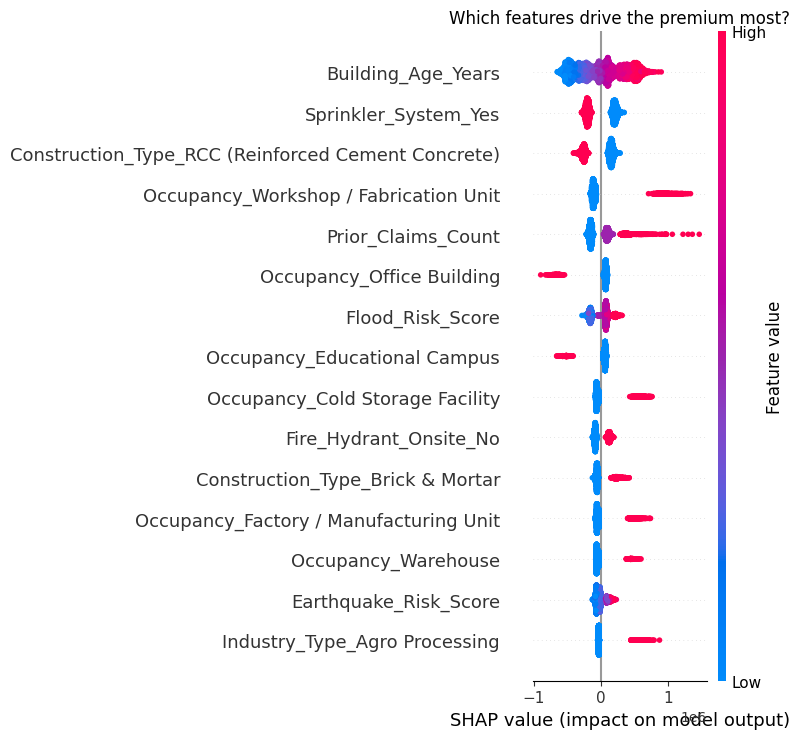

Saved: shap_summary_plot.png


In [12]:
shap.summary_plot(shap_values, X, max_display=15, show=False)
plt.title("Which features drive the premium most?")
plt.tight_layout()
plt.savefig("shap_summary_plot.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: shap_summary_plot.png")

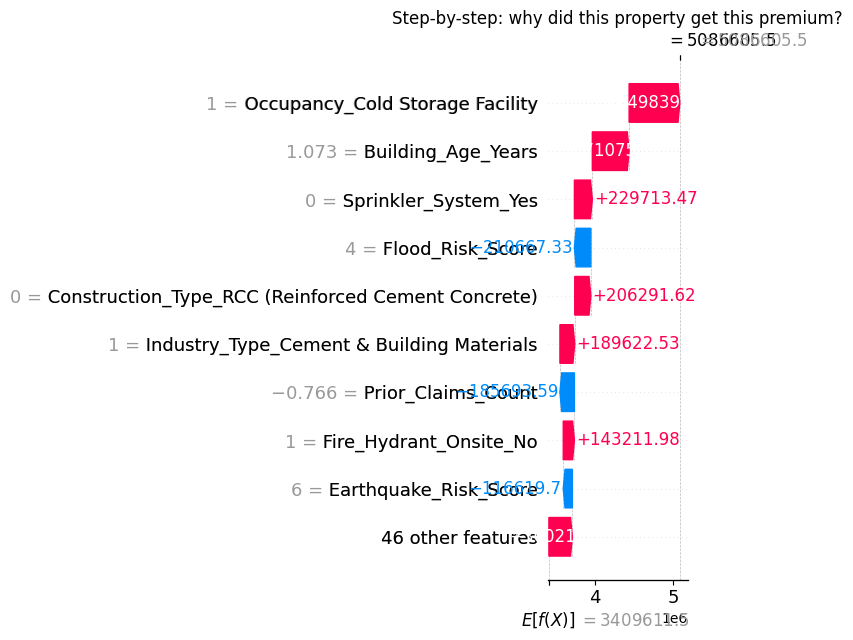

Saved: shap_waterfall_example.png


In [13]:
sample_idx = df[df["Risk_Label"] == "High"].index[0]

shap.waterfall_plot(
    shap.Explanation(
        values        = shap_values[sample_idx],
        base_values   = explainer.expected_value,
        data          = X.iloc[sample_idx],
        feature_names = X.columns.tolist()
    ),
    show=False
)
plt.title("Step-by-step: why did this property get this premium?")
plt.tight_layout()
plt.savefig("shap_waterfall_example.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: shap_waterfall_example.png")

In [14]:
shap_df = pd.DataFrame(shap_values, columns=X.columns)
shap_df.to_csv("shap_values.csv", index=False)

with open("shap_explainer.pkl", "wb") as f:
    pickle.dump(explainer, f)

print("Saved: shap_values.csv")
print("Saved: shap_explainer.pkl")

Saved: shap_values.csv
Saved: shap_explainer.pkl


In [18]:
def get_price_and_explanation(submission_dict):
    with open("freq_model.pkl",         "rb") as f: freq_model       = pickle.load(f)
    with open("sev_model.pkl",          "rb") as f: sev_model        = pickle.load(f)
    with open("xgb_model.pkl",          "rb") as f: xgb_model        = pickle.load(f)
    with open("shap_explainer.pkl",     "rb") as f: explainer        = pickle.load(f)
    with open("glm_feature_columns.pkl","rb") as f: glm_feature_cols = pickle.load(f)

    import importlib.util
    spec   = importlib.util.spec_from_file_location(
                 "preprocess_submission", "preprocess_submission.py")
    module = importlib.util.module_from_spec(spec)
    spec.loader.exec_module(module)
    preprocess_submission = module.preprocess_submission

    # Preprocess the live submission
    df_input = pd.DataFrame([submission_dict])
    df_clean = preprocess_submission(df_input)

    # ---- FIX: align columns to match GLM training columns exactly ----
    df_glm = sm.add_constant(df_clean, has_constant="add")

    # Add any missing columns with 0
    for col in glm_feature_cols:
        if col not in df_glm.columns:
            df_glm[col] = 0

    # Remove any extra columns not seen during training
    df_glm = df_glm[glm_feature_cols]
    # ------------------------------------------------------------------

    freq_pred   = float(freq_model.predict(df_glm).iloc[0])
    sev_pred    = float(sev_model.predict(df_glm).iloc[0])
    glm_premium = freq_pred * sev_pred

    # XGBoost uses the cleaned version (not GLM version)
    # Also align XGBoost columns
    xgb_feature_cols = xgb_model.get_booster().feature_names
    for col in xgb_feature_cols:
        if col not in df_clean.columns:
            df_clean[col] = 0
    df_clean_xgb = df_clean[xgb_feature_cols]

    xgb_pred      = float(xgb_model.predict(df_clean_xgb)[0])

    UPLIFT_CAP    = 0.40
    uplift        = (xgb_pred - glm_premium) / glm_premium
    capped_uplift = float(np.clip(uplift, -UPLIFT_CAP, UPLIFT_CAP))
    final_premium = glm_premium * (1 + capped_uplift)

    shap_vals     = explainer.shap_values(df_clean_xgb)[0]
    feature_names = df_clean_xgb.columns.tolist()
    top_features  = sorted(
        zip(feature_names, shap_vals),
        key=lambda x: abs(x[1]),
        reverse=True
    )[:3]

    explanation = [
        {
            "feature":     name,
            "shap_impact": round(float(val), 4),
            "direction":   "increases premium" if val > 0 else "reduces premium"
        }
        for name, val in top_features
    ]

    return {
        "glm_baseline_INR":   round(glm_premium, 2),
        "xgb_prediction_INR": round(xgb_pred, 2),
        "uplift_pct":         round(capped_uplift * 100, 2),
        "final_premium_INR":  round(final_premium, 2),
        "top_shap_features":  explanation
    }

# Test it
test_submission = {
    "Occupancy":           "Warehouse",
    "Construction_Type":   "Brick & Mortar",
    "Industry_Type":       "Textiles & Garments",
    "Building_Age_Years":  25,
    "Sum_Insured_INR":     40000000,
    "Number_of_Employees": 120,
    "Years_in_Business":   10,
    "Prior_Claims_Count":  2,
    "Deductible_INR":      100000,
    "Sprinkler_System":    "No",
    "Fire_Hydrant_Onsite": "Yes",
    "Requested_Coverage":  "Standard Fire & Special Perils",
    "District":            "Surat"
}

result = get_price_and_explanation(test_submission)

print("=" * 50)
print("PRICING AGENT TEST")
print("=" * 50)
print(f"GLM Baseline:  INR {result['glm_baseline_INR']:,.2f}")
print(f"XGBoost:       INR {result['xgb_prediction_INR']:,.2f}")
print(f"Uplift:        {result['uplift_pct']}%")
print(f"Final Premium: INR {result['final_premium_INR']:,.2f}")
print()
print("Top 3 risk drivers:")
for f in result["top_shap_features"]:
    print(f"  {f['feature']}: {f['direction']} (SHAP = {f['shap_impact']})")

PRICING AGENT TEST
GLM Baseline:  INR 4,440,540.40
XGBoost:       INR 4,481,257.00
Uplift:        0.92%
Final Premium: INR 4,481,257.00

Top 3 risk drivers:
  Occupancy_Warehouse: increases premium (SHAP = 473166.375)
  Prior_Claims_Count: increases premium (SHAP = 430399.625)
  Sprinkler_System_Yes: increases premium (SHAP = 257167.1562)


In [19]:
from google.colab import files
files.download("glm_feature_columns.pkl")
print("Downloaded: glm_feature_columns.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Downloaded: glm_feature_columns.pkl


In [20]:
code = '''
import pandas as pd
import numpy as np
import pickle
import statsmodels.api as sm
import importlib.util

UPLIFT_CAP = 0.40

def get_price_and_explanation(submission_dict):
    with open("freq_model.pkl",          "rb") as f: freq_model       = pickle.load(f)
    with open("sev_model.pkl",           "rb") as f: sev_model        = pickle.load(f)
    with open("xgb_model.pkl",           "rb") as f: xgb_model        = pickle.load(f)
    with open("shap_explainer.pkl",      "rb") as f: explainer        = pickle.load(f)
    with open("glm_feature_columns.pkl", "rb") as f: glm_feature_cols = pickle.load(f)

    spec   = importlib.util.spec_from_file_location(
                 "preprocess_submission", "preprocess_submission.py")
    module = importlib.util.module_from_spec(spec)
    spec.loader.exec_module(module)
    preprocess_submission = module.preprocess_submission

    df_input = pd.DataFrame([submission_dict])
    df_clean = preprocess_submission(df_input)

    # Align GLM columns
    df_glm = sm.add_constant(df_clean, has_constant="add")
    for col in glm_feature_cols:
        if col not in df_glm.columns:
            df_glm[col] = 0
    df_glm = df_glm[glm_feature_cols]

    freq_pred   = float(freq_model.predict(df_glm).iloc[0])
    sev_pred    = float(sev_model.predict(df_glm).iloc[0])
    glm_premium = freq_pred * sev_pred

    # Align XGBoost columns
    xgb_feature_cols = xgb_model.get_booster().feature_names
    for col in xgb_feature_cols:
        if col not in df_clean.columns:
            df_clean[col] = 0
    df_clean_xgb = df_clean[xgb_feature_cols]

    xgb_pred      = float(xgb_model.predict(df_clean_xgb)[0])
    uplift        = (xgb_pred - glm_premium) / glm_premium
    capped_uplift = float(np.clip(uplift, -UPLIFT_CAP, UPLIFT_CAP))
    final_premium = glm_premium * (1 + capped_uplift)

    shap_vals     = explainer.shap_values(df_clean_xgb)[0]
    feature_names = df_clean_xgb.columns.tolist()
    top_features  = sorted(
        zip(feature_names, shap_vals),
        key=lambda x: abs(x[1]),
        reverse=True
    )[:3]

    explanation = [
        {
            "feature":     name,
            "shap_impact": round(float(val), 4),
            "direction":   "increases premium" if val > 0 else "reduces premium"
        }
        for name, val in top_features
    ]

    return {
        "glm_baseline_INR":   round(glm_premium, 2),
        "xgb_prediction_INR": round(xgb_pred, 2),
        "uplift_pct":         round(capped_uplift * 100, 2),
        "final_premium_INR":  round(final_premium, 2),
        "top_shap_features":  explanation
    }
'''

with open("pricing_agent.py", "w") as f:
    f.write(code)

print("pricing_agent.py updated and saved.")

pricing_agent.py updated and saved.
